----------------------
#### Visualizing the embeddings in 2D
---------------------------

- Utilizing t-SNE to reduce the dimensionality of embeddings from 1536 to 2.
- After the dimensionality reduction, the embeddings will be represented in two dimensions.
- The resulting 2D embeddings can be visualized through a scatter plot.

#### 1. Reduce dimensionality
We reduce the dimensionality to 2 dimensions using t-SNE decomposition.

In [1]:
import pandas as pd

from sklearn.manifold import TSNE

import numpy as np
from ast import literal_eval

In [2]:
# Load the embeddings
datafile_path = r"D:\AI-DATASETS\02-MISC-large\GenAI-LLMs\amazon_food_reviews_with_embeddings_2k.csv"
df = pd.read_csv(datafile_path)

In [3]:
df.shape

(2000, 9)

In [4]:
df.sample(3)

,Unnamed: 0,ProductId,UserId,Score,Summary,Text,combined,n_tokens,ada_embedding
1975,481010,B004ZY34NC,A4IL0CLL27Q33,1,Buyer beware,Nespresso makes GREAT coffee and GREAT machine...,Title: Buyer beware; Content: Nespresso makes ...,108,"[-0.06634359061717987, -0.021260106936097145, ..."
1679,464364,B000UBD88A,AWRFQYLG7LQKJ,2,Not very strong,Not as strong as the regular dark coffee. Dis...,Title: Not very strong; Content: Not as strong...,45,"[-0.04050746187567711, -0.01693718321621418, -..."
183,110044,B007PA30ZU,A34YL36NCRLSQT,5,Great Morning Coffee,This is a great morning starter!! If you love...,Title: Great Morning Coffee; Content: This is ...,38,"[-0.0005136529798619449, -0.036049388349056244..."


In [5]:
# Convert to a list of lists of floats
matrix = np.array(df.ada_embedding.apply(literal_eval).to_list())

In [6]:
# Create a t-SNE model and transform the data
tsne = TSNE(n_components =2, 
            # perplexity   =15, 
            # random_state =42, 
            # init         ='random', 
            # learning_rate=200
           )

vis_dims = tsne.fit_transform(matrix)

vis_dims.shape

(2000, 2)

In [7]:
#pip install umap-learn

In [7]:
import umap

In [8]:
# Create a UMAP model and transform the data
umap_model = umap.UMAP(n_components=2, 
                        n_neighbors=15, 
                        min_dist=0.1, 
                        random_state=42)

vis_dims = umap_model.fit_transform(matrix)
vis_dims.shape

D:\python_envs\genai_gpt_lc_vdb_trnsf\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


(2000, 2)

#### 2. Plotting the embeddings
We colour each review by its star rating, ranging from red to green.

We can observe a decent data separation even in the reduced 2 dimensions.

In [9]:
import matplotlib.pyplot as plt
import matplotlib
import numpy as np

In [10]:
colors = ["red", "darkorange", "gold", "turquoise", "darkgreen"]

In [11]:
x = [x for x,y in vis_dims]
y = [y for x,y in vis_dims]
color_indices = df.Score.values - 1

In [12]:
colormap = matplotlib.colors.ListedColormap(colors)

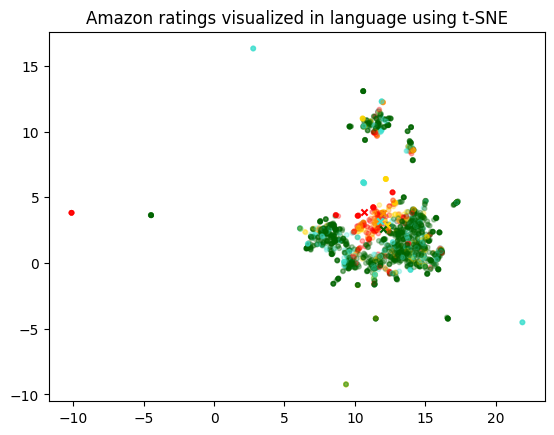

In [13]:
plt.scatter(x, y, c=color_indices, cmap=colormap, alpha=0.3, s=10)

for score in [0,1,2,3,4]:
    avg_x = np.array(x)[df.Score-1==score].mean()
    avg_y = np.array(y)[df.Score-1==score].mean()
    color = colors[score]
    plt.scatter(avg_x, avg_y, marker='x', color=color, s=20)

plt.title("Amazon ratings visualized in language using t-SNE");

The visualization seems to have produced roughly 3 clusters, one of which has mostly negative reviews.